## **Исследование предпочтений зрителей франшизы «Звёздные войны»**

В данном проекте проводится анализ [результатов опроса](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey), посвященного франшизе Star Wars. Основное внимание уделено подготовке данных к анализу, исследованию предпочтений респондентов и выявлению закономерностей в оценках фильмов серии.

In [1]:
#Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
%matplotlib inline

Загружаем данные в датафрейм с использованием кодировки ISO-8859-1:

In [2]:
df = pd.read_csv('star_wars.csv', encoding = 'ISO-8859-1')

Выведем первые пять строк:

In [3]:
df.head()

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Which of the following Star Wars films have you seen? Please select all that apply.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,...,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,3292879998,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3.0,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
1,3292879538,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
2,3292765271,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1.0,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
3,3292763116,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5.0,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
4,3292731220,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5.0,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


Так как датафрейм содержит много столбцов, предварительно изучим количество пропущенных значений в каждом из них с помощью тепловой карты (пропуски обозначены белым цветом):

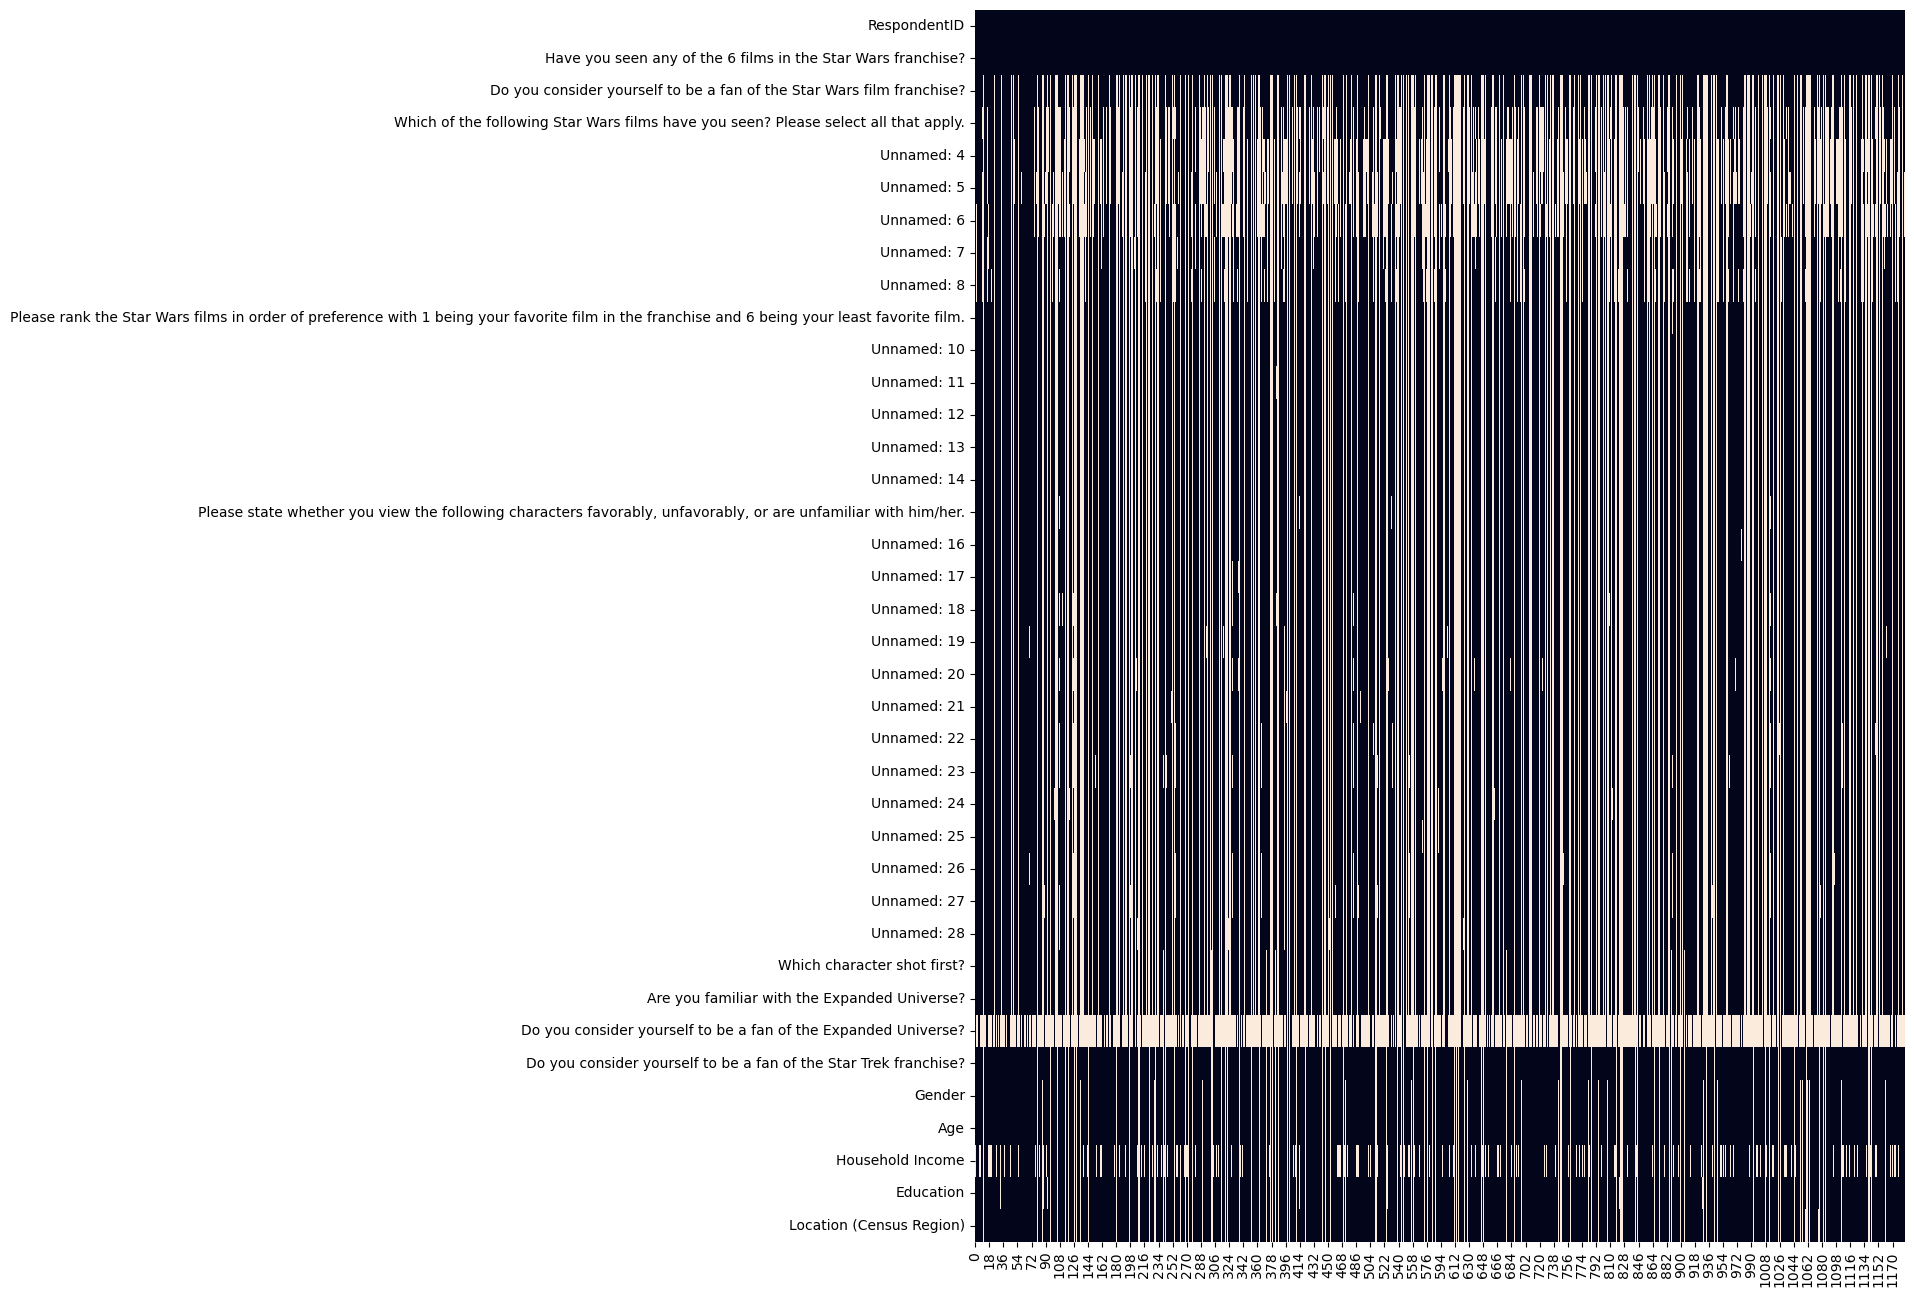

In [4]:
plt.figure(figsize = (12, 16))
sns.heatmap(df.isnull().T, cbar = False)
plt.show()

В результатах опроса наблюдается интересная и немного непривычная структура данных: после общих вопросов в таблице представлено несколько столбцов с названиями вида `Unnamed: 4`, `Unnamed: 5` и так далее. Предположительно, они связаны между собой в рамках одного вопроса.

Чтобы определить назначение этих столбцов и корректно интерпретировать данные, изучим набор уникальных значений для каждого из них:

In [5]:
unnamed_columns = [col for col in df.columns if 'Unnamed' in col]

for col in unnamed_columns:
    print(df[col].value_counts(dropna = False))
    print()

Unnamed: 4
NaN                                            615
Star Wars: Episode II  Attack of the Clones    571
Name: count, dtype: int64

Unnamed: 5
NaN                                            636
Star Wars: Episode III  Revenge of the Sith    550
Name: count, dtype: int64

Unnamed: 6
Star Wars: Episode IV  A New Hope    607
NaN                                  579
Name: count, dtype: int64

Unnamed: 7
Star Wars: Episode V The Empire Strikes Back    758
NaN                                             428
Name: count, dtype: int64

Unnamed: 8
Star Wars: Episode VI Return of the Jedi    738
NaN                                         448
Name: count, dtype: int64

Unnamed: 10
NaN    350
5.0    300
4.0    183
2.0    116
3.0    103
6.0    102
1.0     32
Name: count, dtype: int64

Unnamed: 11
NaN    351
6.0    217
5.0    203
4.0    182
3.0    150
2.0     47
1.0     36
Name: count, dtype: int64

Unnamed: 12
NaN    350
1.0    204
6.0    161
2.0    135
4.0    130
3.0    127
5.0     79
Nam

Полученные значения подтвердили наши предположения. Структура опроса построена таким образом, что после каждого составного вопроса располагаются несколько дополнительных столбцов, каждый из которых соответствует отдельному варианту ответа на этот вопрос. Из-за такой организации данных их необходимо рассматривать и анализировать отдельными блоками, поскольку взаимосвязь между столбцами сохраняется только внутри конкретных групп вопросов.

Для дальнейшей работы выделим следующие тематические блоки:

1) `Which of the following Star Wars films have you seen? Please select all that apply.` Данный вопрос относится к просмотру фильмов серии. После него следуют столбцы с названиями эпизодов, где `Unnamed: 4` - эпизод II, `Unnamed: 5` - эпизод III и т.д. Отметки в этих столбцах показывают, какие фильмы были просмотрены каждым респондентом:

In [6]:
df.iloc[:, 3:9].head(4)

,Which of the following Star Wars films have you seen? Please select all that apply.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN
3,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi


Можно заметить, что основной вопрос уже содержит вариант ответа, связанный с просмотром первого эпизода. Для удобства дальнейшего анализа необходимо привести данные к читаемому формату: заменить непонятные названия столбцов на информативные, а значения – на логические `True`/`False`. Это позволит легко определить, какие фильмы были просмотрены каждым респондентом, и упростит дальнейшую обработку данных:

In [7]:
df.rename({'Which of the following Star Wars films have you seen? Please select all that apply.': 'episode_1_seen',
           'Unnamed: 4': 'episode_2_seen',
           'Unnamed: 5': 'episode_3_seen',
           'Unnamed: 6': 'episode_4_seen',
           'Unnamed: 7': 'episode_5_seen',
           'Unnamed: 8': 'episode_6_seen'        
}, inplace = True, axis = 1)

episode_seen_cols = [col for col in df.columns if '_seen' in col]
df[episode_seen_cols].head(4)

,episode_1_seen,episode_2_seen,episode_3_seen,episode_4_seen,episode_5_seen,episode_6_seen
0,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN
3,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi


In [8]:
for col in episode_seen_cols:
    df[col] = df[col].notnull()
    #Выведем преобразованные значения для проверки правильности замены
    print(df[col].value_counts(dropna = False))
    print()
# Создадим новый столбец, отражающий общее количество просмотренных эпизодов респондентом
df['total_seen'] = df[episode_seen_cols].sum(axis = 1)

episode_1_seen
True     673
False    513
Name: count, dtype: int64

episode_2_seen
False    615
True     571
Name: count, dtype: int64

episode_3_seen
False    636
True     550
Name: count, dtype: int64

episode_4_seen
True     607
False    579
Name: count, dtype: int64

episode_5_seen
True     758
False    428
Name: count, dtype: int64

episode_6_seen
True     738
False    448
Name: count, dtype: int64



Полученные результаты показывают, что все значения были корректно преобразованы в булевое представление. Перейдём к следующей группе вопросов:

2) `Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.` Данный вопрос относится к ранжированию фильмов серии по степени предпочтения (6 - наиболее низкая оценка). За ним следуют столбцы с названиями эпизодов, где `Unnamed: 10` соответствует эпизоду II, `Unnamed: 11` – эпизоду III и т.д. Значения в этих столбцах показывают, какое место в рейтинге респондент присвоил каждому фильму.

In [9]:
df.iloc[:, 9:15].head(4)

,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,3.0,2.0,1.0,4.0,5.0,6.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,2.0,3.0,4.0,5.0,6.0
3,5.0,6.0,1.0,2.0,4.0,3.0


Аналогично, основной вопрос уже содержит вариант ответа, связанный с первым эпизодом. Приведём данные столбцы к читаемому формату, заменив их названия на информативные:

In [10]:
df.rename({'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.': 'episode_1_rank',
           'Unnamed: 10': 'episode_2_rank',
           'Unnamed: 11': 'episode_3_rank',
           'Unnamed: 12': 'episode_4_rank',
           'Unnamed: 13': 'episode_5_rank',
           'Unnamed: 14': 'episode_6_rank'        
}, inplace = True, axis = 1)

episode_rank_cols = [col for col in df.columns if '_rank' in col]
df[episode_rank_cols].info()
df[episode_rank_cols].head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   episode_1_rank  835 non-null    float64
 1   episode_2_rank  836 non-null    float64
 2   episode_3_rank  835 non-null    float64
 3   episode_4_rank  836 non-null    float64
 4   episode_5_rank  836 non-null    float64
 5   episode_6_rank  836 non-null    float64
dtypes: float64(6)
memory usage: 55.7 KB


,episode_1_rank,episode_2_rank,episode_3_rank,episode_4_rank,episode_5_rank,episode_6_rank
0,3.0,2.0,1.0,4.0,5.0,6.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,2.0,3.0,4.0,5.0,6.0
3,5.0,6.0,1.0,2.0,4.0,3.0


Теперь по названиям столбцов понятно, что они относятся к рейтингу каждого эпизода. Перейдём к следующей явной группе вопросов:

3) `Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.` – этот блок вопросов посвящён восприятию персонажей: респонденты могли выразить положительное или отрицательное отношение либо отметить, что не знакомы с персонажем. Рассмотрим структуру этих данных подробнее:

In [11]:
df.loc[:, 'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.': 'Unnamed: 28'].head()

,"Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.",Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
0,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A)
3,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
4,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very unfavorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Somewhat favorably,Somewhat favorably


По количеству столбцов можно определить, что респондентам предлагалось оценить 14 различных персонажей всей саги. Однако информация о соответствии персонажей конкретным столбцам в исходном наборе данных отсутствует. С помощью дополнительных электронных источников, в частности статьи на платформе [Medium](https://medium.com/analytics-vidhya/star-wars-survey-cleaning-exploring-data-set-for-beginners-cf2be950feaa), удалось восстановить данную информацию. Переименуем столбцы для повышения их информативности:

In [12]:
df.rename({'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.': 'Han_Solo_rank',
           'Unnamed: 16': 'Luke_Skywalker_rank',
           'Unnamed: 17': 'Princess_Leia_Organa_rank',
           'Unnamed: 18': 'Anakin_Skywalker_rank',
           'Unnamed: 19': 'Obi_Wan_Kenobi_rank',
           'Unnamed: 20': 'Emperor_Palpatine_rank',
           'Unnamed: 21': 'Darth_Vader_rank', 
           'Unnamed: 22': 'Lando_Calrissian_rank', 
           'Unnamed: 23': 'Boba_Fett_rank', 
           'Unnamed: 24': 'C-3P0_rank', 
           'Unnamed: 25': 'R2_D2_rank', 
           'Unnamed: 26': 'Jar_Jar_Binks_rank', 
           'Unnamed: 27': 'Padme_Amidala_rank', 
           'Unnamed: 28': 'Yoda_rank', 
}, inplace = True, axis = 1)

df.loc[:, 'Han_Solo_rank': 'Yoda_rank'].head()

,Han_Solo_rank,Luke_Skywalker_rank,Princess_Leia_Organa_rank,Anakin_Skywalker_rank,Obi_Wan_Kenobi_rank,Emperor_Palpatine_rank,Darth_Vader_rank,Lando_Calrissian_rank,Boba_Fett_rank,C-3P0_rank,R2_D2_rank,Jar_Jar_Binks_rank,Padme_Amidala_rank,Yoda_rank
0,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A)
3,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
4,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very unfavorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Somewhat favorably,Somewhat favorably


На этом этапе предварительная очистка данных завершена: все столбцы из описанных выше тематических блоков приведены к стандартизированному формату.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 39 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   RespondentID                                                           1186 non-null   int64  
 1   Have you seen any of the 6 films in the Star Wars franchise?           1186 non-null   object 
 2   Do you consider yourself to be a fan of the Star Wars film franchise?  836 non-null    object 
 3   episode_1_seen                                                         1186 non-null   bool   
 4   episode_2_seen                                                         1186 non-null   bool   
 5   episode_3_seen                                                         1186 non-null   bool   
 6   episode_4_seen                                                         1186 non-null   b

Продолжим изучение оставшихся столбцов. Поскольку одной из целей анализа является исследование профилей респондентов на основе их ответов, особый интерес представляют следующие столбцы:

- `Do you consider yourself to be a fan of the Star Wars film franchise?`
- `Gender`
- `Age`

In [14]:
respondents_characteristics = ['Do you consider yourself to be a fan of the Star Wars film franchise?',
                               'Gender',
                               'Age']
df[respondents_characteristics].dtypes

Do you consider yourself to be a fan of the Star Wars film franchise?    object
Gender                                                                   object
Age                                                                      object
dtype: object

Как видно из результатов, `Do you consider yourself to be a fan of the Star Wars film franchise?` и `Age` имеют тип данных object. Рассмотрим значения в указанных столбцах, чтобы определить их структуру и принять решение о необходимости изменения типа данных:

In [15]:
df['Do you consider yourself to be a fan of the Star Wars film franchise?'].value_counts(dropna = False)

Do you consider yourself to be a fan of the Star Wars film franchise?
Yes    552
NaN    350
No     284
Name: count, dtype: int64

В столбце `Do you consider yourself to be a fan of the Star Wars film franchise?` ответы представлены в виде категориальных значений `Yes` и `No`. Преобразуем их в булевый формат, что упростит дальнейший анализ и группировку данных:

In [16]:
df['Do you consider yourself to be a fan of the Star Wars film franchise?'] = df['Do you consider yourself to be a fan of the Star Wars film franchise?'].map(lambda x: True if x == 'Yes' else False)
df['Do you consider yourself to be a fan of the Star Wars film franchise?'].value_counts(dropna = False)

Do you consider yourself to be a fan of the Star Wars film franchise?
False    634
True     552
Name: count, dtype: int64

Теперь изучим значения в столбце `Age`:

In [17]:
df['Age'].value_counts(dropna = False)

Age
45-60    291
> 60     269
30-44    268
18-29    218
NaN      140
Name: count, dtype: int64

Возраст участников опроса представлен в виде интервалов. Хотя такая форма несколько обобщает данные, она сохраняет исходное распределение респондентов по возрастным группам. Преобразование интервальных значений в целочисленный формат потребовало бы присвоения условных числовых значений, что могло бы привести к искажению данных и, как следствие, некорректной интерпретации результатов. Поэтому изменение данного столбца не требуется.

---

### Визуализации

Сравним показатели просмотров и средние оценки эпизодов в двух группах – среди фанатов саги и тех, кто не относит себя к этой категории.

In [18]:
# Приводим данные о просмотре эпизодов к длинному формату
episodes_seen_melt = pd.melt(df, id_vars = ['Do you consider yourself to be a fan of the Star Wars film franchise?'], 
                             value_vars = ['episode_1_seen','episode_2_seen','episode_3_seen','episode_4_seen','episode_5_seen','episode_6_seen'])
# Разделяем данные на две группы: фанатов и не-фанатов саги
fans_episodes_seen_melt = episodes_seen_melt[episodes_seen_melt['Do you consider yourself to be a fan of the Star Wars film franchise?'] == True]
not_fans_episodes_seen_melt = episodes_seen_melt[episodes_seen_melt['Do you consider yourself to be a fan of the Star Wars film franchise?'] == False]


# Приводим данные об оценках эпизодов к длинному формату
episodes_rank_melt = pd.melt(df, id_vars = ['Do you consider yourself to be a fan of the Star Wars film franchise?'], 
                             value_vars = ['episode_1_rank','episode_2_rank','episode_3_rank','episode_4_rank','episode_5_rank','episode_6_rank'])
# Аналогично разделяем их на две группы
fans_episodes_rank_melt = episodes_rank_melt[episodes_rank_melt['Do you consider yourself to be a fan of the Star Wars film franchise?'] == True]
not_fans_episodes_rank_melt = episodes_rank_melt[episodes_rank_melt['Do you consider yourself to be a fan of the Star Wars film franchise?'] == False]

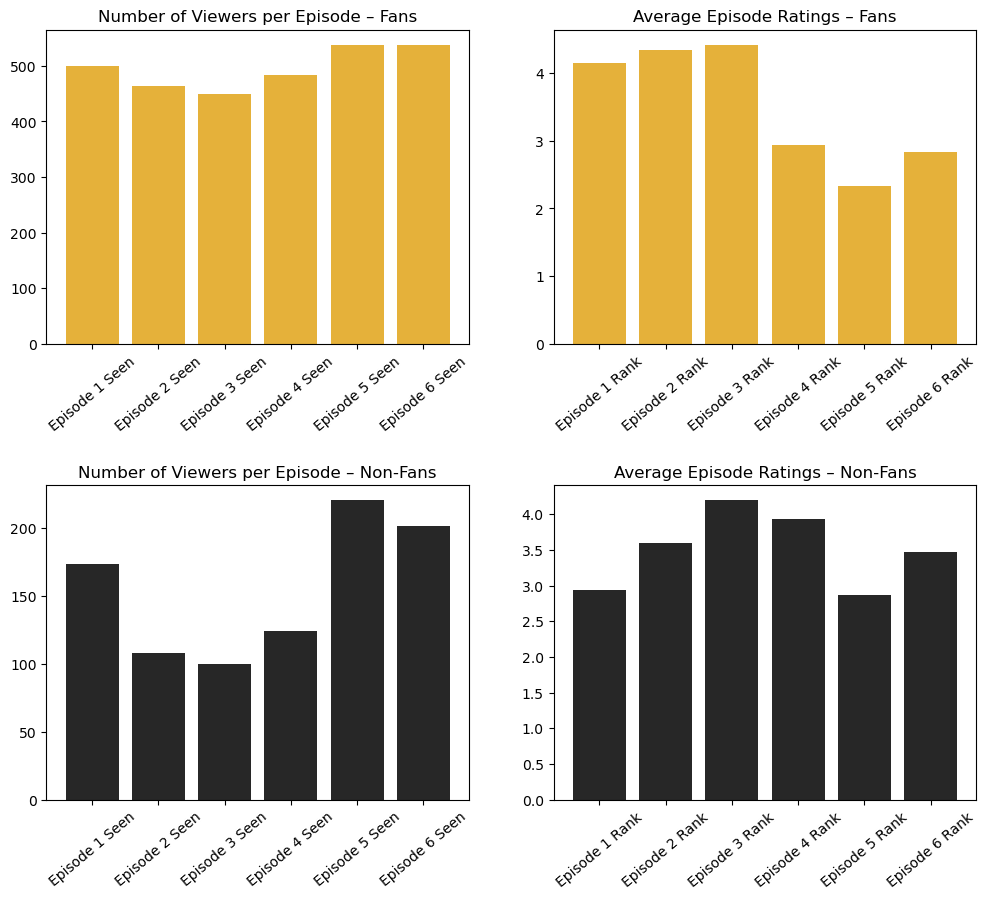

In [19]:
# Создаём область для четырёх сравнительных графиков
plt.figure(figsize = (12, 10))
plt.subplots_adjust(wspace=0.2, hspace=0.45)

# Создаём сводные таблицы для подсчёта количества респондентов, посмотревших каждый эпизод
fans_episodes_seen_pivot = fans_episodes_seen_melt.pivot_table(index = 'variable', values = 'value', aggfunc = 'sum')
not_fans_episodes_seen_pivot = not_fans_episodes_seen_melt.pivot_table(index = 'variable', values = 'value', aggfunc = 'sum')

# Создаём сводные таблицы для расчёта средней оценки каждого эпизода
fans_episodes_rank_pivot = fans_episodes_rank_melt.pivot_table(index = 'variable', values = 'value', aggfunc = 'mean')
not_fans_episodes_rank_pivot = not_fans_episodes_rank_melt.pivot_table(index = 'variable', values = 'value', aggfunc = 'mean')

# Преобразуем названия эпизодов для отображения на графиках
bar_headers = [fans_episodes_seen_pivot, not_fans_episodes_seen_pivot, fans_episodes_rank_pivot, not_fans_episodes_rank_pivot]
for header in bar_headers:
    header.index = header.index.str.replace("_", " ").str.title()

# Сами графики (столбчатые диаграммы)
# 1 график:
plt.subplot(2, 2, 1)
plt.bar(x = fans_episodes_seen_pivot.index, height = fans_episodes_seen_pivot['value'], color = "#e5b13a", label = 'fdfFDFDDFd')
plt.title("Number of Viewers per Episode – Fans")

# 2 график:
plt.subplot(2, 2, 2)
plt.bar(x = fans_episodes_rank_pivot.index, height = fans_episodes_rank_pivot['value'], color = "#e5b13a")
plt.title("Average Episode Ratings – Fans")

# 3 график:
plt.subplot(2, 2, 3)
plt.bar(x = not_fans_episodes_seen_pivot.index, height = not_fans_episodes_seen_pivot['value'], color = "#272727")
plt.title("Number of Viewers per Episode – Non-Fans")

# 4 график:
plt.subplot(2, 2, 4)
plt.bar(x = not_fans_episodes_rank_pivot.index, height = not_fans_episodes_rank_pivot['value'], color = "#272727")
plt.title("Average Episode Ratings – Non-Fans")

# Настраиваем для всех графиков наклон меток на оси x
for i in range (1, 5):
    plt.subplot(2, 2, i)
    plt.xticks(rotation = 40)
    
plt.show()

В представленных данных можно заметить одну интересную закономерность: на всех четырёх графиках третий эпизод имеет наихудшие показатели как по количеству просмотров, так и по средним оценкам.

Полученный результат кажется весьма неожиданным, поскольку [«Месть ситхов»](https://www.kinopoisk.ru/film/5619/) считается одним из наиболее популярных и высоко оценённых эпизодов саги. Например, на сайте «Кинопоиск» фильм имеет рейтинг 8,1 и занимает `122-е` место в рейтинге «Топ-250».

<div style="text-align: center;">
  <img src="SW_posters.jpg" alt="Постеры всех эпизодов Звёздных войн" style="display: block; margin: 0 auto;">
</div>


| Эпизод | Количество оценок | Рейтинг | Рецензии |
|---|:-:|--:|--:|
| **[Эпизод 1 – Скрытая угроза (1999)](https://www.kinopoisk.ru/film/6695/)** | 392777 | 7.9 | 144 |
| **[Эпизод 2 – Атака клонов (2002)](https://www.kinopoisk.ru/film/844/)** | 320583 | 8.0 | 116 |
| **[Эпизод 3 – Месть ситхов (2005)](https://www.kinopoisk.ru/film/5619/)** | `411772` | 8.1 | 187 |
| **[Эпизод 4 – Новая надежда (1977)](https://www.kinopoisk.ru/film/333/)** | 350503 | 8.1 | 138 |
| **[Эпизод 5 – Империя наносит ответный удар (1980)](https://www.kinopoisk.ru/film/338/)** | 322860 | 8.1 | 99 |
| **[Эпизод 6 – Возвращение Джедая (1983)](https://www.kinopoisk.ru/film/447/)** | 305792 | 8.2 | 92 |

Возникает естественный вопрос: чем может быть обусловлено такое парадоксальное расхождение во мнениях? Одним из возможных факторов может выступать восприятие главных героев, поскольку именно они во многом определяют сюжет и общее впечатление от фильма. В связи с этим изучим отношение респондентов к персонажам саги.

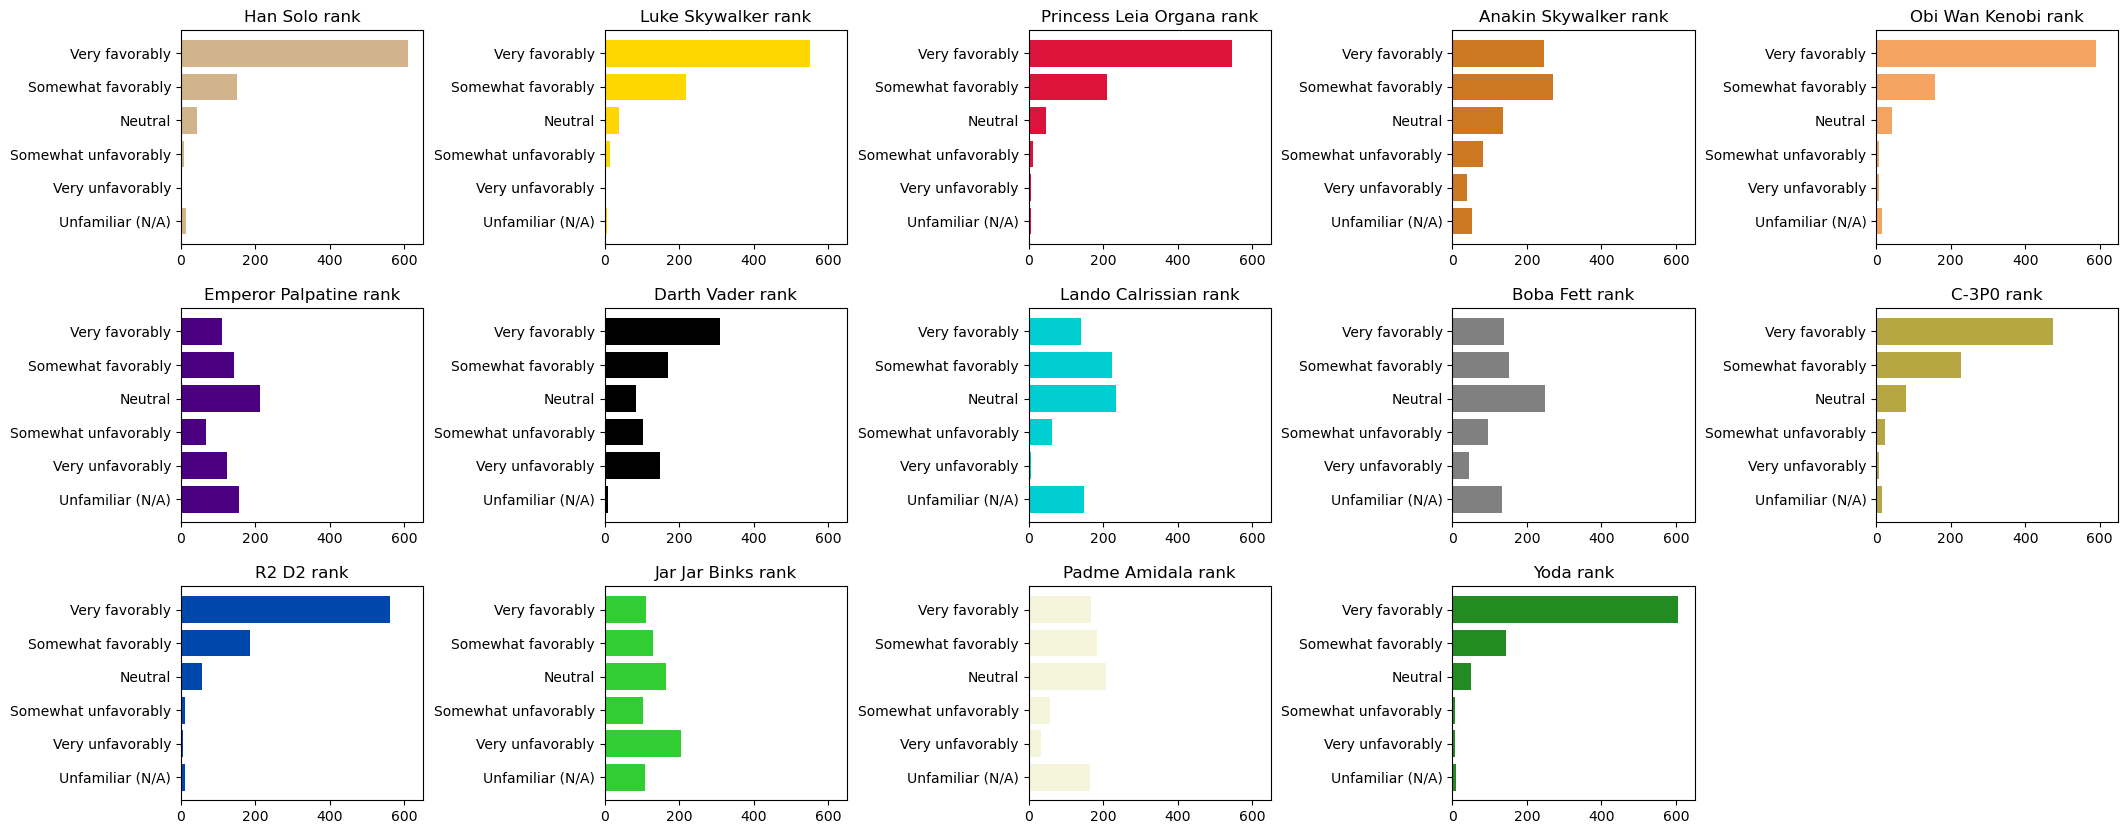

In [20]:
plt.figure(figsize = (25, 10))
plt.subplots_adjust(wspace=0.75, hspace=0.3)

# Из датафрейма черег регулярное выражение выбираем все столбцы с оценками персонажей
characters_columns = [col for col in df.columns if re.search("(?<!episode_[\d])_rank", col)]

# Цвета для каждого персонажа были сгенерированы нейросетью Яндекс Алиса:
colors = [
    '#D2B48C',  # Han Solo – песочно‑бежевый оттенок его жилета
    '#FFD700',  # Luke Skywalker – золотой элемент на костюме пилота
    '#DC143C',  # Princess Leia Organa – насыщенный красный, как её решимость
    '#CC7722',  # Anakin Skywalker – тёплый охристый тон, отсылающий к Татуину
    '#F4A460',  # Obi‑Wan Kenobi – землистый цвет одеяний джедая
    '#4B0082',  # Emperor Palpatine – мрачный тёмно‑фиолетовый, символ власти и тьмы
    '#000000',  # Darth Vader – классический чёрный цвет брони
    '#00CED1',  # Lando Calrissian – бирюзовый акцент, элегантный и яркий
    '#808080',  # Boba Fett – стальной оттенок брони охотника за головами
    '#B5A642',  # C‑3P0 – латунный цвет корпуса дроида
    '#0047AB',  # R2‑D2 – ярко‑синий, основной цвет корпуса дроида
    '#32CD32',  # Jar Jar Binks – светло‑зелёный, характерный для гунганов
    '#F5F5DC',  # Padme Amidala – цвет слоновой кости, как в её церемониальных нарядах
    '#228B22'   # Yoda – тёмно‑зелёный, оттенок кожи мастера‑джедая
]

# Общая шкала оценки для каждого персонажа: от наиболее положительной к наиболее отрицательной
order = [
    'Unfamiliar (N/A)',
    'Very unfavorably',
    'Somewhat unfavorably',
    'Neither favorably nor unfavorably (neutral)',
    'Somewhat favorably',
    'Very favorably'
]

# Для каждого персонажа отдельно строим график:
for character, color, i in zip(characters_columns, colors, range(1, 15)):
    # Получаем все оценки для конкретного персонажа
    character_ranks = df[character].value_counts()
    # Стандартизируем порядок индексов в серии в соответствии со шкалой оценки персонажей
    character_ranks = character_ranks.reindex(order, fill_value=0)
    
    # Сокращаем название варианта ответа, чтобы графики не перекрывали друг друга
    character_ranks.index = character_ranks.index.str.replace('Neither favorably nor unfavorably (neutral)', "Neutral")
    
    plt.subplot(3, 5, i)
    plt.barh(y = character_ranks.index, width = character_ranks.values, color = color)
    
    # Убираем нижние подчёркивания в названии графика для повышения читабельности 
    plt.title(character.replace("_", " "))
    # Приводим ось X к общему масштабу: от 0 до 650
    plt.xlim(0, 650)

plt.show()

Исходя из полученных оценок, можно отметить неоднозначное отношение респондентов к персонажам, характерным для второй и третьей частей саги, среди которых фигурируют Энакин и Падме. Вместе с тем, вариант ответа `Unfamiliar (N/A)` также чаще всего встречается именно в отношении этих героев.

Это может свидетельствовать о двух возможных сценариях:
- С одной стороны, часть респондентов могла не смотреть первые три эпизода и, как следствие, не иметь представления о соответствующих персонажах.
- С другой же, респонденты могли быть знакомы с ними, но негативно относиться к их сюжетным аркам, в частности к истории Энакина и Падме.

На данном этапе установить причину такой закономерности невозможно. Тем не менее, одним из возможных объяснений столь неоднозначного отношения к главным героям может служить возраст респондентов. Такое предположение связано с уровнем осознания глубины персонажей и их мотивов. Представители разных возрастных групп могут совершенно иначе воспринимать поступки героев и понимать причины, приведшие к определённым решениям. Энакин Скайуокер является одним из таких примеров: его история строится вокруг стремления к признанию, силе и желанию защитить близких, которое постепенно приводит его к радикальному изменению. Схожий пример можно найти в образе Гриффита из аниме «Берсерк». 

*Важно подчеркнуть, что возраст не тождественен мудрости или зрелости личности, однако он в определённой степени отражает социальную и культурную среду, в которой формировались взгляды человека. В отсутствие альтернативных данных о жизненном опыте или ценностях возраст остаётся одним из немногих доступных показателей, позволяющих проверить эту гипотезу.*


Построим диаграммы рассеяния, чтобы оценить взаимосвязь между оценками второго и третьего эпизодов с учётом возраста респондентов и их отношения к Энакину Скайуокеру:

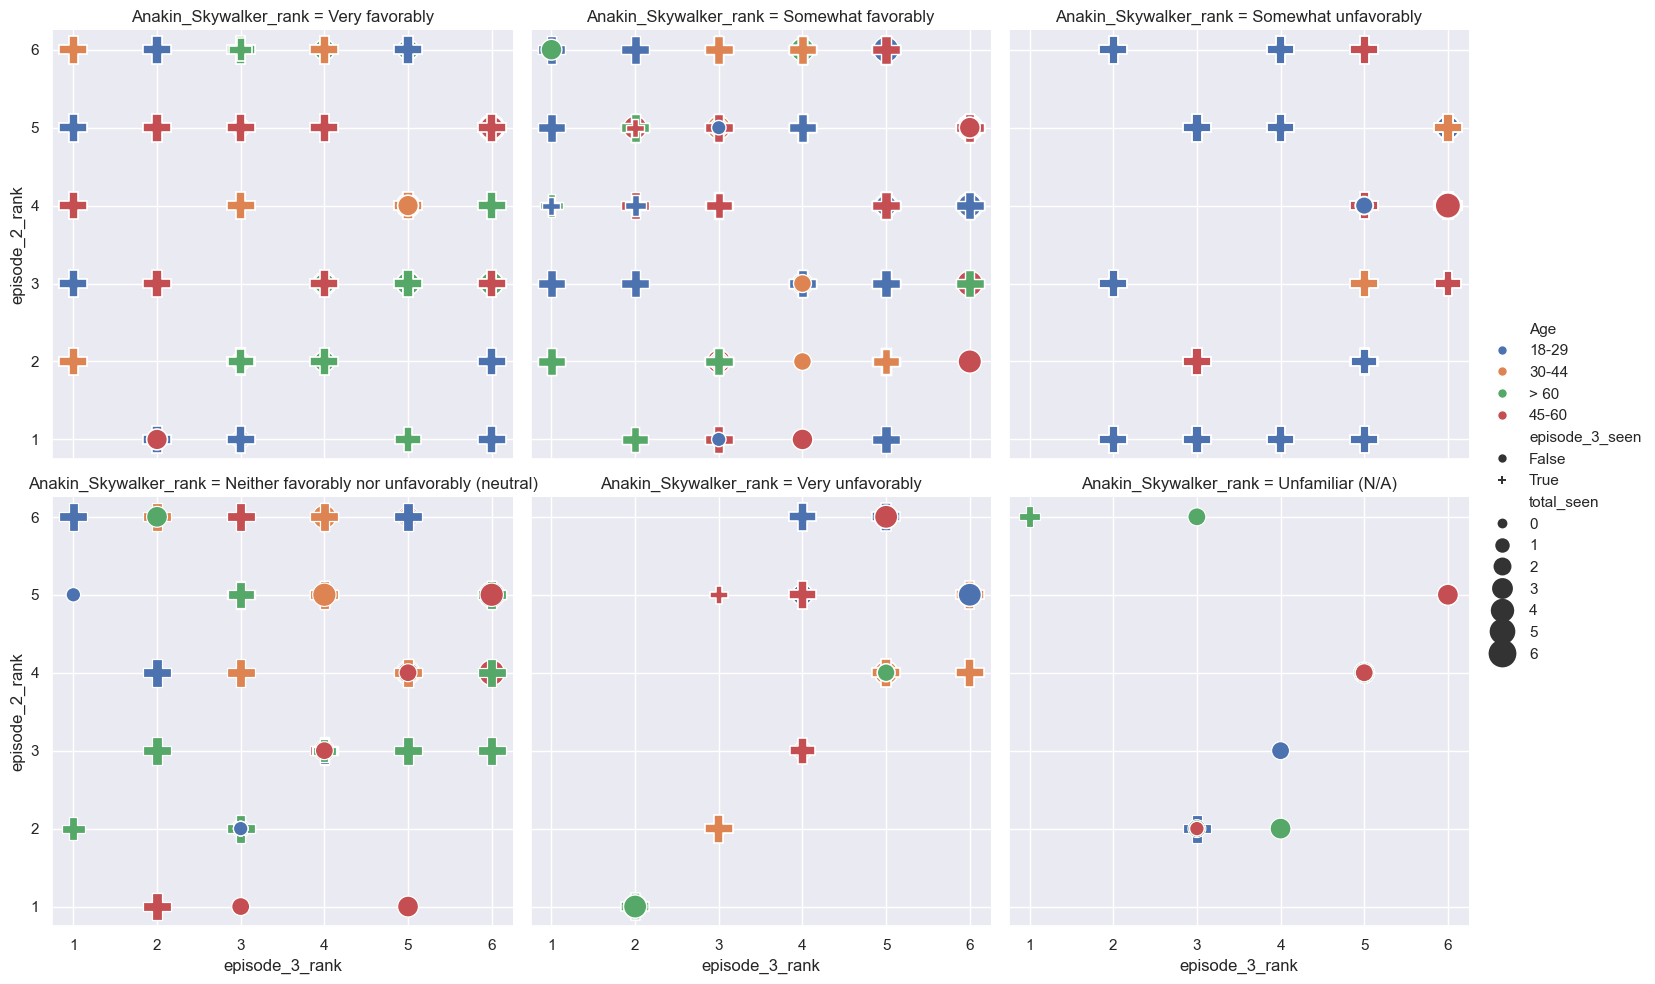

In [21]:
sns.set_theme()
sns.relplot(data = df, x = 'episode_3_rank',
                       y = 'episode_2_rank',
                       hue = 'Age',
                       size = 'total_seen',
                       sizes = (50, 400),
                       style = 'episode_3_seen',
                       markers = {True: 'P',
                                  False: 'o'},
                       col = 'Anakin_Skywalker_rank',
                       col_wrap = 3)
                
plt.show()

По всей видимости, выдвинутая мною гипотеза не нашла подтверждения в представленных данных. Графики не показывают выраженной связи между возрастной группой респондентов и оценками эпизодов: представители разных возрастных групп распределены по диаграммам без заметных закономерностей или устойчивых тенденций.

Примечательно, что индивидуальные оценки второго и третьего эпизодов нередко существенно расходятся: один и тот же респондент может высоко оценить один фильм и крайне низко – другой. Учитывая, что оба эпизода продолжают единую сюжетную линию, а поступки и судьбы персонажей в них неразрывно связаны, такой контраст в оценках выглядит особенно выразительно.

Особого внимания заслуживают случаи, когда респонденты выставляли оценку третьему эпизоду, одновременно указывая, что не смотрели его. Парадокс заключается в том, что именно в третьем эпизоде раскрывается ключевой переход от Энакина Скайуокера к Дарту Вейдеру – одному из наиболее узнаваемых персонажей массовой культуры. В связи с этим возникает два закономерных вопроса: 
- Что лежало в основе такой оценки, если респондент, согласно собственному ответу, не знаком с содержанием фильма?
- Насколько адекватно зритель способен оценивать последующие части саги, не имея представления о поворотном моменте в судьбе главного героя?

Подводя итоги, визуальный анализ не выявил выраженных закономерностей между возрастом респондентов и оценками эпизодов. Однако при большом количестве наблюдений отдельные взаимосвязи могут быть незаметны на диаграммах. Поэтому проверим сделанные выводы количественно, рассчитав коэффициенты корреляции Пирсона. Перед этим преобразуем категориальные признаки в числовой формат, сохранив порядок соответствующих категорий:

In [22]:
age_regroup_dict = {'18-29': 1,
                    '30-44': 2,
                    '45-60': 3,
                    '> 60': 4,    
}

rank_regroup_dict = {'Very favorably': 5,
                     'Somewhat favorably': 4,
                     'Neither favorably nor unfavorably (neutral)': 3,
                     'Somewhat unfavorably': 2,
                     'Very unfavorably': 1
}
    
df['Age_numeric'] = df['Age'].map(age_regroup_dict)
df['Anakin_Skywalker_rank_numeric'] = df['Anakin_Skywalker_rank'].map(rank_regroup_dict)

print(f"Корреляция оценок второго и третьего эпизодов: {df['episode_3_rank'].corr(df['episode_2_rank']):.3f}")
print(f"Корреляция возраста и оценки третьего эпизода: {df['episode_3_rank'].corr(df['Age_numeric']):.3f}")
print(f"Корреляция отношения к Энакину Скайуокеру и оценки третьего эпизода: {df['Anakin_Skywalker_rank_numeric'].corr(df['episode_3_rank']):.3f}")

Корреляция ранжирования второго и третьего эпизода: 0.336
Корреляция возраста и ранжирования третьего эпизода: 0.084
Корреляция оценки Энакина Скайуокера и ранжирования третьего эпизода: -0.099


Полученные коэффициенты в целом соответствуют предполагаемому направлению взаимосвязей: между оценками второго и третьего эпизодов наблюдается положительная корреляция (0,336), между возрастом и оценкой третьего эпизода – слабая положительная (0,084), а между отношением к Энакину и оценкой третьего эпизода – слабая отрицательная (-0,099). При этом абсолютные значения коэффициентов невелики, поэтому выраженной линейной связи между рассматриваемыми признаками не обнаружено.

Интерпретацию этих результатов следует проводить с учётом ограничений исходных данных. Во-первых, выборка относительно невелика, что ограничивает возможность выявления слабых взаимосвязей. Во-вторых, возраст респондентов представлен интервальными группами, поэтому участники, фактически находящиеся на разных концах одного возрастного диапазона, получают одно и то же числовое значение. Наличие точного возраста и более подробной информации о жизненном опыте, ценностях и условиях формирования взглядов позволило бы провести более содержательный анализ выдвинутой гипотезы.

Наконец, существенное значение имеет временной контекст исследования. Сам опрос проводился около 12 лет назад, то есть в 2014 году, тогда как внешняя оценка фильма, с которой сопоставлялись его результаты, отражает восприятие аудитории уже в 2026 году. Например, на текущий момент [«Месть ситхов»](https://www.kinopoisk.ru/film/5619/) сохраняет рейтинг 8,1 на «Кинопоиске» и входит в Топ-250. Таким образом, различия между результатами опроса и современной внешней оценкой могут быть связаны не только с особенностями самой выборки, но и с изменением аудитории и культурного контекста за прошедшее десятилетие.